# Assignment 3

Run every cell top-to-bottom. All outputs are written to `outputs/`.

In [1]:
!pip install torch transformers datasets sentencepiece faiss-cpu tqdm numpy accelerate huggingface_hub matplotlib numpy nltk ipywidgets -q

In [2]:
!pip install "git+https://github.com/k4black/codebleu.git" --no-deps -q
!pip install "tree-sitter>=0.24.0" "tree-sitter-java" setuptools nltk -q

In [3]:
import os, re, json, pickle, random, shutil, warnings
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from datasets import load_dataset
from transformers import (
    T5Config, T5ForConditionalGeneration,
    AutoTokenizer, AutoModel, AutoModelForCausalLM,
)
import sentencepiece as spm
import faiss
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

# Output directories
for _d in ['outputs/tokenizer', 'outputs/pretrained',
           'outputs/finetuned_a', 'outputs/finetuned_b',
           'outputs/rag', 'outputs/results']:
    os.makedirs(_d, exist_ok=True)

VOCAB_SIZE      = 16_384
NUM_METHODS     = 50_000
sentinel_tokens = [f'<extra_id_{i}>' for i in range(100)]
print(f"VOCAB_SIZE = {VOCAB_SIZE}  |  sentinels: {len(sentinel_tokens)}")

Device: cuda
VOCAB_SIZE = 16384  |  sentinels: 100


## Part 1 — Custom SentencePiece Tokenizer

In [4]:
corpus_file  = 'outputs/pretrain_corpus.txt'
model_prefix = 'outputs/tokenizer/sp_tokenizer'

print(f'Downloading {NUM_METHODS:,} Java methods from CodeSearchNet…')
csn          = load_dataset('code_search_net', 'java')
java_samples = csn['train'].shuffle(seed=SEED).select(range(NUM_METHODS))
all_methods  = [s['whole_func_string'] for s in java_samples]
print(f'Downloaded {len(all_methods):,} methods')

with open(corpus_file, 'w', encoding='utf-8') as _fh:
    for _m in all_methods:
        _line = _m.strip().replace('\n', ' ').replace('\r', ' ')
        if _line:
            _fh.write(_line + '\n')

_n_lines = sum(1 for _ in open(corpus_file, encoding='utf-8'))
_n_bytes = os.path.getsize(corpus_file)
print(f'Corpus: {_n_lines:,} lines  {_n_bytes/1024/1024:.1f} MB written to {corpus_file}')
assert _n_lines > 1000, f'Corpus too small: {_n_lines} lines'

Downloaded 50,000 methods
Corpus: 50,000 lines  34.0 MB written to outputs/pretrain_corpus.txt


In [5]:
shutil.rmtree('outputs/tokenizer', ignore_errors=True)
os.makedirs('outputs/tokenizer')

_sentinel_str = ','.join(sentinel_tokens)
_cmd = (
    f'--input={corpus_file} '
    f'--model_prefix={model_prefix} '
    '--model_type=unigram '
    f'--vocab_size={VOCAB_SIZE} '
    '--character_coverage=0.9999 '
    '--pad_id=0 --pad_piece=<pad> '
    '--eos_id=1 --eos_piece=</s> '
    '--unk_id=2 --unk_piece=<unk> '
    '--bos_id=-1 '
    f'--user_defined_symbols={_sentinel_str} '
    '--num_threads=4 '
    '--input_sentence_size=500000 '
    '--shuffle_input_sentence=true'
)
print(f'Training SP tokenizer  (vocab_size={VOCAB_SIZE})…')
spm.SentencePieceTrainer.train(_cmd)

_sp_raw = spm.SentencePieceProcessor()
_sp_raw.Load(f'{model_prefix}.model')
_actual = _sp_raw.GetPieceSize()
print(f'SP vocab size: {_actual}  (expected {VOCAB_SIZE})')
assert _actual == VOCAB_SIZE, (
    f'SP training produced {_actual} tokens, expected {VOCAB_SIZE}.'
)

_sid0 = _sp_raw.PieceToId('<extra_id_0>')
_sid99 = _sp_raw.PieceToId('<extra_id_99>')
print(f'  <extra_id_0> to ID {_sid0}   (expected 3)')
print(f'  <extra_id_99> to ID {_sid99}  (expected 102)')
assert _sid0 == 3,   f'<extra_id_0> should be 3, got {_sid0}'
assert _sid99 == 102, f'<extra_id_99> should be 102, got {_sid99}'

_java = 'public int add(int a, int b) { return a + b; }'
_raw_ids = _sp_raw.EncodeAsIds(_java)
_n_unk   = sum(1 for t in _raw_ids if t == 2)
assert _n_unk == 0, f'Raw SP produces {_n_unk} <unk> tokens for Java!'
print(f'Java sample: {len(_raw_ids)} tokens, 0 <unk>')
print('SP training OK!')

Training SP tokenizer  (vocab_size=16384)…
SP vocab size: 16384  (expected 16384)
  <extra_id_0> to ID 3   (expected 3)
  <extra_id_99> to ID 102  (expected 102)
Java sample: 17 tokens, 0 <unk>
SP training OK!


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=outputs/pretrain_corpus.txt --model_prefix=outputs/tokenizer/sp_tokenizer --model_type=unigram --vocab_size=16384 --character_coverage=0.9999 --pad_id=0 --pad_piece=<pad> --eos_id=1 --eos_piece=</s> --unk_id=2 --unk_piece=<unk> --bos_id=-1 --user_defined_symbols=<extra_id_0>,<extra_id_1>,<extra_id_2>,<extra_id_3>,<extra_id_4>,<extra_id_5>,<extra_id_6>,<extra_id_7>,<extra_id_8>,<extra_id_9>,<extra_id_10>,<extra_id_11>,<extra_id_12>,<extra_id_13>,<extra_id_14>,<extra_id_15>,<extra_id_16>,<extra_id_17>,<extra_id_18>,<extra_id_19>,<extra_id_20>,<extra_id_21>,<extra_id_22>,<extra_id_23>,<extra_id_24>,<extra_id_25>,<extra_id_26>,<extra_id_27>,<extra_id_28>,<extra_id_29>,<extra_id_30>,<extra_id_31>,<extra_id_32>,<extra_id_33>,<extra_id_34>,<extra_id_35>,<extra_id_36>,<extra_id_37>,<extra_id_38>,<extra_id_39>,<extra_id_40>,<extra_id_41>,<extra_id_42>,<extra_id_43>,<extra_id_44>,<extra_id_45>,<extra_id_46>,<extra_id_47>,<extra_id_

In [6]:
class SPTokenizer:
    """
    Thin wrapper around SentencePieceProcessor that exposes the interface
    T5 training expects (encode / decode / special token IDs / __len__).
    Uses the raw SP processor directly to avoid T5Tokenizer version bugs.
    """

    def __init__(self, model_file: str, vocab_size: int,
                 sentinel_tokens: list,
                 pad_id: int = 0, eos_id: int = 1, unk_id: int = 2):
        self.sp = spm.SentencePieceProcessor()
        self.sp.Load(model_file)
        self._vocab_size   = vocab_size
        self.pad_token_id  = pad_id
        self.eos_token_id  = eos_id
        self.unk_token_id  = unk_id
        self.bos_token_id  = pad_id
        self.sentinel_ids  = [
            int(self.sp.PieceToId(t))
            for t in sentinel_tokens
        ]
        self._model_file   = model_file

    # ── Core interface ────────────────────────────────────────────────────

    def __len__(self) -> int:
        return self._vocab_size

    def encode(self, text: str, max_length: int = None,
               truncation: bool = False,
               add_special_tokens: bool = True) -> list:
        ids = self.sp.EncodeAsIds(text)
        cap = (max_length - 1) if (add_special_tokens and max_length) else max_length
        if truncation and cap and len(ids) > cap:
            ids = ids[:cap]
        if add_special_tokens:
            ids = ids + [self.eos_token_id]
        return ids

    def decode(self, ids, skip_special_tokens: bool = True) -> str:
        if hasattr(ids, 'tolist'):
            ids = ids.tolist()
        ids = [int(i) for i in ids if int(i) >= 0]
        if skip_special_tokens:
            drop = ({self.pad_token_id, self.eos_token_id, self.unk_token_id}
                    | set(self.sentinel_ids))
            ids = [i for i in ids if i not in drop]
        return self.sp.DecodeIds(ids)

    def convert_tokens_to_ids(self, token: str) -> int:
        return int(self.sp.PieceToId(token))

    def save_pretrained(self, directory: str) -> None:
        os.makedirs(directory, exist_ok=True)
        shutil.copy(self._model_file,
                    os.path.join(directory, 'spiece.model'))


# Instantiate once; reuse across all parts
tokenizer = SPTokenizer(
    model_file=f'{model_prefix}.model',
    vocab_size=VOCAB_SIZE,
    sentinel_tokens=sentinel_tokens,
)
print(f'Tokenizer ready.  len={len(tokenizer)}')
print(f'  pad={tokenizer.pad_token_id}  '
      f'eos={tokenizer.eos_token_id}  '
      f'unk={tokenizer.unk_token_id}')
print(f'  sentinel_ids[0]={tokenizer.sentinel_ids[0]}  '
      f'sentinel_ids[99]={tokenizer.sentinel_ids[99]}')

Tokenizer ready.  len=16384
  pad=0  eos=1  unk=2
  sentinel_ids[0]=3  sentinel_ids[99]=102


In [7]:
# 1. Vocab size
assert len(tokenizer) == VOCAB_SIZE, (
    f'len(tokenizer)={len(tokenizer)}, expected {VOCAB_SIZE}'
)

# 2. Sentinel tokens resolve to correct IDs
print('Sentinel spot-check:')
for _i in [0, 1, 50, 99]:
    _tok = f'<extra_id_{_i}>'
    _id  = tokenizer.convert_tokens_to_ids(_tok)
    assert _id == 3 + _i, f'{_tok} → {_id}, expected {3+_i}'
    print(f'  {_tok} = {_id}: Good')

#Java code encodes without <unk>
_sample = 'public int add(int a, int b) { return a + b; }'
_ids    = tokenizer.encode(_sample, add_special_tokens=False)
_n_unk  = sum(1 for t in _ids if t == tokenizer.unk_token_id)
assert _n_unk == 0, f'{_n_unk}/{len(_ids)} tokens are <unk>!'

# Round-trip encode then decode
_dec = tokenizer.decode(_ids)
print(f'\nEncode to decode:')
print(f'  in : {_sample}')
print(f'  out: {_dec}')
print('\nAll tokenizer sanity checks passed')

Sentinel spot-check:
  <extra_id_0> = 3: Good
  <extra_id_1> = 4: Good
  <extra_id_50> = 53: Good
  <extra_id_99> = 102: Good

Encode to decode:
  in : public int add(int a, int b) { return a + b; }
  out: public int add(int a, int b) { return a + b; }

All tokenizer sanity checks passed


In [8]:
MIN_TOK, MAX_TOK = 10, 512
pretrain_data = []
for _m in tqdm(all_methods, desc='Filtering corpus'):
    _n = len(tokenizer.encode(_m, add_special_tokens=False))
    if MIN_TOK <= _n <= MAX_TOK:
        pretrain_data.append(_m)

print(f'Pre-training corpus: {len(pretrain_data):,} out of {len(all_methods):,} methods kept')
with open('outputs/pretrain_methods.pkl', 'wb') as _fh:
    pickle.dump(pretrain_data, _fh)
print('Corpus saved to outputs/pretrain_methods.pkl')

Filtering corpus: 100%|██████████| 50000/50000 [00:01<00:00, 30500.81it/s]

Pre-training corpus: 48,070 out of 50,000 methods kept
Corpus saved to outputs/pretrain_methods.pkl


## Part 2

**Architecture**
T5-small — 6 encoder + 6 decoder layers, d_model = 512, d_ff = 2 048, 8 attention heads ≈ 60 M parameters, randomly initialised.

In [9]:
PT_EPOCHS    = 3
PT_BATCH     = 8
PT_LR        = 1e-4
PT_MAX_LEN   = 128
PT_MASK_RATE = 0.15


sentinel_ids = tokenizer.sentinel_ids
assert len(sentinel_ids) == 100
print(f'sentinel_ids : {sentinel_ids[:5]} … {sentinel_ids[-1]}')

sentinel_ids : [3, 4, 5, 6, 7] … 102


In [10]:
def apply_span_corruption(ids_tensor: torch.Tensor,
                          mask_rate: float = 0.15):
    """
    T5-style span corruption.
    Returns (encoder_input, decoder_target) as 1-D LongTensors.
    """
    ids    = ids_tensor.squeeze()
    length = ids.size(0)
    _eos   = tokenizer.eos_token_id
    _pad   = tokenizer.pad_token_id

    protected = {_eos, _pad} | set(sentinel_ids)
    eligible  = [i for i in range(length)
                 if ids[i].item() not in protected]

    if not eligible:
        return ids, torch.tensor([sentinel_ids[0], _eos], dtype=torch.long)

    n_corrupt  = max(1, min(int(len(eligible) * mask_rate), len(eligible)))
    corrupt_pos = set(random.sample(eligible, n_corrupt))

    # Group adjacent positions into spans
    spans: list = []
    cur:   list = []
    for pos in sorted(corrupt_pos):
        if cur and pos != cur[-1] + 1:
            spans.append(cur); cur = []
        cur.append(pos)
    if cur:
        spans.append(cur)
    spans = spans[:len(sentinel_ids) - 1]   # one sentinel closes the target

    # Encoder input
    enc: list = []
    k, i = 0, 0
    while i < length:
        if k < len(spans) and i == spans[k][0]:
            enc.append(sentinel_ids[k])
            i = spans[k][-1] + 1
            k += 1
        else:
            enc.append(ids[i].item()); i += 1
    enc.append(_eos)

    # Decoder target
    dec: list = []
    for k2, span in enumerate(spans):
        dec.append(sentinel_ids[k2])
        dec.extend(ids[p].item() for p in span)
    dec.append(sentinel_ids[len(spans)])
    dec.append(_eos)

    return (torch.tensor(enc, dtype=torch.long),
            torch.tensor(dec, dtype=torch.long))


print('apply_span_corruption defined.')

apply_span_corruption defined.


In [11]:
class PretrainDataset(Dataset):
    """Tokenises upfront; applies fresh random span corruption on every access."""

    def __init__(self, corpus: list, max_len: int = 128):
        self.seqs = [
            tokenizer.encode(text, max_length=max_len,
                             truncation=True, add_special_tokens=True)
            for text in corpus
        ]
        print(f'PretrainDataset: {len(self.seqs):,} sequences')

    def __len__(self) -> int:
        return len(self.seqs)

    def __getitem__(self, idx):
        t = torch.tensor(self.seqs[idx], dtype=torch.long)
        enc, dec = apply_span_corruption(t, PT_MASK_RATE)
        return {'input_ids': enc, 'labels': dec}


def pt_collate(batch):
    """Pad encoder inputs and decoder targets to the batch maximum length."""
    pad  = tokenizer.pad_token_id
    inps = [b['input_ids'] for b in batch]
    labs = [b['labels']    for b in batch]
    max_i = max(x.size(0) for x in inps)
    max_l = max(y.size(0) for y in labs)
    P_in  = torch.full((len(batch), max_i),  pad,  dtype=torch.long)
    mask  = torch.zeros((len(batch), max_i),        dtype=torch.long)
    P_lab = torch.full((len(batch), max_l), -100,  dtype=torch.long)
    for i, (x, y) in enumerate(zip(inps, labs)):
        P_in[i, :x.size(0)] = x
        mask[i, :x.size(0)] = 1
        P_lab[i, :y.size(0)] = y
    return {'input_ids': P_in, 'attention_mask': mask, 'labels': P_lab}


pt_dataset = PretrainDataset(pretrain_data, PT_MAX_LEN)
pt_loader  = DataLoader(
    pt_dataset, batch_size=PT_BATCH, shuffle=True,
    collate_fn=pt_collate, num_workers=0,
)
print(f'DataLoader: {len(pt_loader):,} batches / epoch')

PretrainDataset: 48,070 sequences
DataLoader: 6,009 batches / epoch


In [12]:
t5_config = T5Config(
    vocab_size             = len(tokenizer),   # 16 384
    decoder_start_token_id = tokenizer.pad_token_id,   # 0
    eos_token_id           = tokenizer.eos_token_id,   # 1
    bos_token_id           = tokenizer.pad_token_id,   # 0
    d_model        = 512,
    d_ff           = 2048,
    d_kv           = 64,
    num_heads      = 8,
    num_layers     = 6,
    num_decoder_layers = 6,
)
pretrain_model = T5ForConditionalGeneration(config=t5_config)
pretrain_model.resize_token_embeddings(len(tokenizer))
pretrain_model = pretrain_model.to(device)

n_params = sum(p.numel() for p in pretrain_model.parameters()) / 1e6
print(f'T5-small built: {n_params:.1f} M parameters')

T5-small built: 52.4 M parameters


In [13]:
pt_optimizer = torch.optim.AdamW(
    pretrain_model.parameters(), lr=PT_LR, weight_decay=0.01
)
pt_losses: list = []

print(f'Pre-training: {PT_EPOCHS} epochs  |  '
      f'lr={PT_LR}  batch={PT_BATCH}  max_seq_len={PT_MAX_LEN}')

for epoch in range(1, PT_EPOCHS + 1):
    pretrain_model.train()
    total_loss = 0.0
    pbar = tqdm(pt_loader, desc=f'  Pre-train epoch {epoch}/{PT_EPOCHS}')
    for batch in pbar:
        outputs = pretrain_model(
            input_ids      = batch['input_ids'].to(device),
            attention_mask = batch['attention_mask'].to(device),
            labels         = batch['labels'].to(device),
        )
        loss = outputs.loss
        pt_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(pretrain_model.parameters(), 1.0)
        pt_optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    avg = total_loss / len(pt_loader)
    pt_losses.append(avg)
    print(f'  Epoch {epoch}  avg_loss = {avg:.4f}')

print(f'\nPre-training complete.  Epoch losses: {[round(l,4) for l in pt_losses]}')
if len(pt_losses) > 1:
    assert pt_losses[-1] < pt_losses[0], 'Loss did not decrease across epochs'

Pre-training: 3 epochs  |  lr=0.0001  batch=8  max_seq_len=128


  Pre-train epoch 1/3: 100%|██████████| 6009/6009 [02:33<00:00, 39.26it/s, loss=3.7023]


  Epoch 1  avg_loss = 3.7114


  Pre-train epoch 2/3: 100%|██████████| 6009/6009 [02:33<00:00, 39.23it/s, loss=3.3182]


  Epoch 2  avg_loss = 3.4521


  Pre-train epoch 3/3: 100%|██████████| 6009/6009 [02:33<00:00, 39.02it/s, loss=3.1018]

  Epoch 3  avg_loss = 3.4130

Pre-training complete.  Epoch losses: [3.7114, 3.4521, 3.413]


In [14]:
pretrain_model.save_pretrained('outputs/pretrained')
tokenizer.save_pretrained('outputs/pretrained')
with open('outputs/pretrained/pt_losses.json', 'w') as _fh:
    json.dump({'epoch_losses': pt_losses}, _fh, indent=2)
print('Pre-trained model saved to outputs/pretrained/')
print(f'Epoch losses: {pt_losses}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Pre-trained model saved to outputs/pretrained/
Epoch losses: [3.711379041963775, 3.4520842830240874, 3.4130137256346798]


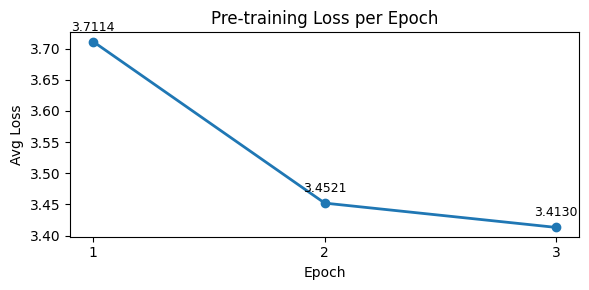

Loss decreased: 3.7114 to 3.4130  (Δ = 0.2984)


In [15]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(pt_losses) + 1))
plt.figure(figsize=(6, 3))
plt.plot(epochs, pt_losses, marker='o', linewidth=2)
for e, l in zip(epochs, pt_losses):
    plt.annotate(f'{l:.4f}', (e, l), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=9)
plt.xlabel('Epoch')
plt.ylabel('Avg Loss')
plt.title('Pre-training Loss per Epoch')
plt.xticks(epochs)
plt.tight_layout()
plt.savefig('outputs/pretrained/loss_curve.png', dpi=100)
plt.show()
print(f'Loss decreased: {pt_losses[0]:.4f} to {pt_losses[-1]:.4f}  '
      f'(Δ = {pt_losses[0]-pt_losses[-1]:.4f})')

## Part 3

In [16]:
MAX_SRC     = 256
MAX_TGT     = 256
FT_BATCH    = 16
FT_LR       = 5e-4
FT_EPOCHS   = 10
FT_PATIENCE = 3
TASK_PREFIX = 'fix bug: '

In [17]:
print('Loading CodeXGLUE bug-fixing dataset')
bugfix_ds  = load_dataset('google/code_x_glue_cc_code_refinement',
                          name='medium')
train_data = list(bugfix_ds['train'])
val_data   = list(bugfix_ds['validation'])
test_data  = list(bugfix_ds['test'])
print(f'Train: {len(train_data):,}  |  Val: {len(val_data):,}  |  Test: {len(test_data):,}')
ex0 = train_data[0]
print(f"\nbuggy : {ex0['buggy']}")
print(f"fixed : {ex0['fixed']}")

Loading CodeXGLUE bug-fixing dataset
Train: 52,364  |  Val: 6,546  |  Test: 6,545

buggy : public static TYPE_1 init ( java.lang.String name , java.util.Date date ) { TYPE_1 VAR_1 = new TYPE_1 ( ) ; VAR_1 . METHOD_1 ( name ) ; java.util.Calendar VAR_2 = java.util.Calendar.getInstance ( ) ; VAR_2 . METHOD_2 ( date ) ; VAR_1 . METHOD_3 ( VAR_2 ) ; return VAR_1 ; }

fixed : public static TYPE_1 init ( java.lang.String name , java.util.Date date ) { TYPE_1 VAR_1 = new TYPE_1 ( ) ; VAR_1 . METHOD_1 ( name ) ; java.util.Calendar VAR_2 = null ; if ( date != null ) { VAR_2 = java.util.Calendar.getInstance ( ) ; VAR_2 . METHOD_2 ( date ) ; } VAR_1 . METHOD_3 ( VAR_2 ) ; return VAR_1 ; }



In [18]:
class BugFixDataset(Dataset):
    def __init__(self, examples: list,
                 max_src: int = 256, max_tgt: int = 256):
        self.srcs = [
            TASK_PREFIX + ex['buggy'].strip() for ex in examples
        ]
        self.tgts = [ex['fixed'].strip() for ex in examples]
        self.max_src = max_src
        self.max_tgt = max_tgt

    def __len__(self) -> int:
        return len(self.srcs)

    def __getitem__(self, idx):
        src = tokenizer.encode(
            self.srcs[idx], max_length=self.max_src,
            truncation=True, add_special_tokens=True)
        tgt = tokenizer.encode(
            self.tgts[idx], max_length=self.max_tgt,
            truncation=True, add_special_tokens=True)
        return {'input_ids': src, 'labels': tgt}


def ft_collate(batch):
    pad  = tokenizer.pad_token_id
    inps = [torch.tensor(b['input_ids'], dtype=torch.long) for b in batch]
    labs = [torch.tensor(b['labels'],    dtype=torch.long) for b in batch]
    max_i = max(x.size(0) for x in inps)
    max_l = max(y.size(0) for y in labs)
    P_in  = torch.full((len(batch), max_i),  pad,  dtype=torch.long)
    mask  = torch.zeros((len(batch), max_i),        dtype=torch.long)
    P_lab = torch.full((len(batch), max_l), -100,  dtype=torch.long)
    for i, (x, y) in enumerate(zip(inps, labs)):
        P_in[i, :x.size(0)] = x
        mask[i, :x.size(0)] = 1
        P_lab[i, :y.size(0)] = y
    return {'input_ids': P_in, 'attention_mask': mask, 'labels': P_lab}


train_ds = BugFixDataset(train_data, MAX_SRC, MAX_TGT)
val_ds   = BugFixDataset(val_data,   MAX_SRC, MAX_TGT)
train_loader = DataLoader(
    train_ds, batch_size=FT_BATCH, shuffle=True,
    collate_fn=ft_collate, num_workers=0)
val_loader = DataLoader(
    val_ds, batch_size=FT_BATCH, shuffle=False,
    collate_fn=ft_collate, num_workers=0)
print(f'Train batches: {len(train_loader):,}  |  '
      f'Val batches: {len(val_loader):,}')

Train batches: 3,273  |  Val batches: 410


In [19]:
def _train_epoch(model, loader, optimizer):
    model.train(); total = 0.0
    for batch in tqdm(loader, desc='    train', leave=False):
        out  = model(
            input_ids      = batch['input_ids'].to(device),
            attention_mask = batch['attention_mask'].to(device),
            labels         = batch['labels'].to(device),
        )
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); optimizer.zero_grad()
        total += out.loss.item()
    return total / len(loader)


def _eval_epoch(model, loader):
    model.eval(); total = 0.0
    with torch.no_grad():
        for batch in tqdm(loader, desc='    val', leave=False):
            out = model(
                input_ids      = batch['input_ids'].to(device),
                attention_mask = batch['attention_mask'].to(device),
                labels         = batch['labels'].to(device),
            )
            total += out.loss.item()
    return total / len(loader)


def fine_tune(model, save_dir: str, label: str) -> list:
    """Fine-tune `model`; early stop on val loss; save best checkpoint."""
    os.makedirs(save_dir, exist_ok=True)
    opt = torch.optim.AdamW(
        model.parameters(), lr=FT_LR, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.5, patience=1, min_lr=1e-6)
    best_val  = float('inf')
    patience  = 0
    history   = []

    print(f'Fine-tuning: {label}')
    print(f'lr={FT_LR}  batch={FT_BATCH}  max_epochs={FT_EPOCHS}  '
          f'patience={FT_PATIENCE}')

    for epoch in range(1, FT_EPOCHS + 1):
        tr = _train_epoch(model, train_loader, opt)
        vl = _eval_epoch(model, val_loader)
        scheduler.step(vl)
        current_lr = opt.param_groups[0]['lr']
        history.append({'epoch': epoch, 'train_loss': tr, 'val_loss': vl,
                        'lr': current_lr})

        marker = ''
        if vl < best_val:
            best_val = vl; patience = 0
            model.save_pretrained(save_dir)
            tokenizer.save_pretrained(save_dir)
            marker = '  BEST'
        else:
            patience += 1
            marker = f'  (patience {patience}/{FT_PATIENCE})'

        print(f'  Epoch {epoch:>2}/{FT_EPOCHS}  '
              f'train={tr:.4f}  val={vl:.4f}  lr={current_lr:.2e}{marker}')

        if patience >= FT_PATIENCE:
            print(f'  Early stopping at epoch {epoch}.')
            break

    with open(os.path.join(save_dir, 'history.json'), 'w') as _fh:
        json.dump(history, _fh, indent=2)
    print(f'Best val loss: {best_val:.4f}  saved to  {save_dir}')
    return history


print('Fine-tuning helpers defined.')

Fine-tuning helpers defined.


In [20]:
# Load the final pre-trained checkpoint
model_a = T5ForConditionalGeneration.from_pretrained(
    'outputs/pretrained').to(device)
print('Pipeline A: pre-trained model loaded from outputs/pretrained/')

history_a = fine_tune(
    model_a, 'outputs/finetuned_a',
    'Pipeline A — Pre-train then Fine-tune')

del model_a; torch.cuda.empty_cache()

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Pipeline A: pre-trained model loaded from outputs/pretrained/
Fine-tuning: Pipeline A — Pre-train then Fine-tune
lr=0.0005  batch=16  max_epochs=10  patience=3


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Epoch  1/10  train=1.4811  val=1.3987  lr=5.00e-04  BEST


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  Epoch  8/10  train=1.3661  val=1.2498  lr=2.50e-04  BEST


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Epoch  9/10  train=1.3511  val=1.2388  lr=2.50e-04  BEST


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Epoch 10/10  train=1.3461  val=1.2121  lr=2.50e-04  BEST
Best val loss: 1.2121  saved to  outputs/finetuned_a


In [21]:
scratch_cfg = T5Config(
    vocab_size             = len(tokenizer),
    decoder_start_token_id = tokenizer.pad_token_id,
    eos_token_id           = tokenizer.eos_token_id,
    bos_token_id           = tokenizer.pad_token_id,
    d_model=512, d_ff=2048, d_kv=64,
    num_heads=8, num_layers=6, num_decoder_layers=6,
)
model_b = T5ForConditionalGeneration(config=scratch_cfg)
model_b.resize_token_embeddings(len(tokenizer))
model_b = model_b.to(device)
n_b = sum(p.numel() for p in model_b.parameters()) / 1e6
print(f'Pipeline B: {n_b:.1f} M random parameters (no pre-training)')

history_b = fine_tune(
    model_b, 'outputs/finetuned_b',
    'Pipeline B — From Scratch then Fine-tune')

del model_b; torch.cuda.empty_cache()

Pipeline B: 52.4 M random parameters (no pre-training)
Fine-tuning: Pipeline B — From Scratch then Fine-tune
lr=0.0005  batch=16  max_epochs=10  patience=3


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Epoch  1/10  train=1.4476  val=1.2910  lr=5.00e-04  BEST


  Epoch  2/10  train=1.4424  val=1.3689  lr=5.00e-04  (patience 1/3)


  Epoch  3/10  train=1.4870  val=1.3460  lr=2.50e-04  (patience 2/3)


...

  Epoch  8/10  train=1.3682  val=1.2527  lr=2.50e-04  BEST


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Epoch  9/10  train=1.3487  val=1.2474  lr=2.50e-04  BEST


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Epoch 10/10  train=1.3409  val=1.2273  lr=2.50e-04  BEST
Best val loss: 1.2273  saved to  outputs/finetuned_b


## Part 4 — RAG Inference (Qwen 2.5-Coder 1.5B)

In [22]:
CODEBERT_MODEL = 'microsoft/codebert-base'
QWEN_MODEL     = 'Qwen/Qwen2.5-Coder-1.5B-Instruct'
TOP_K          = 3      # 3-shot RAG
MAX_TEST       = len(test_data)    # evaluation subset size
CB_BATCH       = 32
CB_MAX_LEN     = 256

In [23]:
print(f'Loading CodeBERT ({CODEBERT_MODEL})…')
cb_tok   = AutoTokenizer.from_pretrained(CODEBERT_MODEL)
cb_model = AutoModel.from_pretrained(CODEBERT_MODEL).to(device)
cb_model.eval()
print('CodeBERT loaded.')


def get_embeddings(texts: list, batch_size: int = 32,
                   max_len: int = 256) -> np.ndarray:
    """Mean-pool CodeBERT last hidden states → float32 numpy array."""
    all_embs = []
    for i in tqdm(range(0, len(texts), batch_size),
                  desc='  embedding', leave=False):
        enc = cb_tok(
            texts[i: i + batch_size],
            padding=True, truncation=True,
            max_length=max_len, return_tensors='pt',
        ).to(device)
        with torch.no_grad():
            out = cb_model(**enc)
        mask   = enc['attention_mask'].unsqueeze(-1).expand(
                     out.last_hidden_state.size()).float()
        summed = (out.last_hidden_state * mask).sum(dim=1)
        count  = mask.sum(dim=1).clamp(min=1e-9)
        all_embs.append((summed / count).cpu().float().numpy())
    return np.vstack(all_embs).astype(np.float32)

Loading CodeBERT (microsoft/codebert-base)…


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CodeBERT loaded.


In [24]:
index_path = 'outputs/rag/faiss_index.bin'
meta_path  = 'outputs/rag/kb_metadata.pkl'

if not os.path.exists(index_path):
    print(f'Building knowledge base from {len(train_data):,} pairs…')
    buggy_texts = [ex['buggy'].strip() for ex in train_data]
    fixed_texts = [ex['fixed'].strip() for ex in train_data]

    print('Encoding buggy methods with CodeBERT…')
    embeddings = get_embeddings(buggy_texts, CB_BATCH, CB_MAX_LEN)
    print(f'Embeddings: {embeddings.shape}')

    index = faiss.IndexFlatL2(embeddings.shape[1])
    index.add(embeddings)
    faiss.write_index(index, index_path)

    kb = [{'buggy': b, 'fixed': f}
          for b, f in zip(buggy_texts, fixed_texts)]
    with open(meta_path, 'wb') as _fh:
        pickle.dump(kb, _fh)
    print(f'FAISS index saved: {index.ntotal:,} vectors → {index_path}')
else:
    print('Loading existing FAISS index…')
    index = faiss.read_index(index_path)
    with open(meta_path, 'rb') as _fh:
        kb = pickle.load(_fh)
    print(f'Loaded: {index.ntotal:,} vectors')

Loading existing FAISS index…
Loaded: 52,364 vectors


In [25]:
def retrieve(query_buggy: str, top_k: int = 3) -> list:
    emb = get_embeddings([query_buggy], batch_size=1, max_len=CB_MAX_LEN)
    dists, idxs = index.search(emb, top_k)
    return [
        {'buggy': kb[i]['buggy'], 'fixed': kb[i]['fixed'],
         'sim': float(1.0 / (1.0 + d))}
        for d, i in zip(dists[0], idxs[0]) if 0 <= i < len(kb)
    ]


def build_rag_prompt(buggy: str, examples: list) -> list:
    """3-shot RAG prompt for Qwen chat template."""
    shots = ''
    for k, ex in enumerate(examples, 1):
        shots += (f'\nExample {k} — Buggy:\n```java\n{ex["buggy"]}\n```\n'
                  f'Fixed:\n```java\n{ex["fixed"]}\n```\n')
    user = (
        'Fix the following buggy Java method.\n\n'
        f'Here are {len(examples)} similar bug fixes for reference:{shots}\n'
        'Output ONLY the fixed Java method, nothing else.\n\n'
        f'Buggy:\n```java\n{buggy}\n```\nFixed:\n```java'
    )
    return [{'role': 'system',
             'content': 'You are an expert Java developer specializing in bug fixing.'},
            {'role': 'user', 'content': user}]


def build_zeroshot_prompt(buggy: str) -> list:
    user = (
        'Fix the following buggy Java method.\n'
        'Output ONLY the fixed Java method, nothing else.\n\n'
        f'Buggy:\n```java\n{buggy}\n```\nFixed:\n```java'
    )
    return [{'role': 'system',
             'content': 'You are an expert Java developer specializing in bug fixing.'},
            {'role': 'user', 'content': user}]


# Quick retrieval test
_q   = test_data[0]['buggy']
_top = retrieve(_q, TOP_K)
print(f'Query (80 chars): {_q[:80]}…')
for k, r in enumerate(_top, 1):
    print(f'  Result {k}: sim={r["sim"]:.4f}  {r["buggy"][:60]}…')

Query (80 chars): public java.lang.String METHOD_1 ( ) { if ( ( METHOD_2 ( ) ) && ( METHOD_3 ( VAR…
  Result 1: sim=0.2132  public java.lang.Void METHOD_1 ( ) { if ( ! ( VAR_1 . METHOD…
  Result 2: sim=0.2095  private boolean METHOD_1 ( ) { VAR_1 = null ; if ( VAR_2 . M…
  Result 3: sim=0.2075  public TYPE_1 METHOD_1 ( ) { if ( ( this . METHOD_2 ( ) ) ||…


In [26]:
print(f'Loading {QWEN_MODEL}…')
qwen_tok = AutoTokenizer.from_pretrained(
    QWEN_MODEL, trust_remote_code=True)
qwen_model = AutoModelForCausalLM.from_pretrained(
    QWEN_MODEL,
    torch_dtype=torch.bfloat16,
    device_map='auto',
    trust_remote_code=True,
)
if qwen_tok.pad_token is None:
    qwen_tok.pad_token = qwen_tok.eos_token
print('Qwen loaded.')


def qwen_generate(messages: list, max_new_tokens: int = 256) -> str:
    text   = qwen_tok.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True)
    inputs = qwen_tok(
        text, return_tensors='pt',
        truncation=True, max_length=3072,
    ).to(qwen_model.device)
    in_len = inputs['input_ids'].shape[1]
    with torch.no_grad():
        out = qwen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=qwen_tok.pad_token_id,
            eos_token_id=qwen_tok.eos_token_id,
        )
    raw = qwen_tok.decode(
        out[0][in_len:], skip_special_tokens=True).strip()
    # Strip markdown fences if Qwen added them
    raw = re.sub(r'^```(?:java)?\s*', '', raw)
    raw = re.sub(r'\s*```.*$', '', raw, flags=re.DOTALL)
    return raw.strip()

Loading Qwen/Qwen2.5-Coder-1.5B-Instruct…


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen loaded.


In [27]:
_rng        = random.Random(SEED)
test_subset = _rng.sample(test_data, min(MAX_TEST, len(test_data)))
print(f'Evaluation subset: {len(test_subset)} examples')
with open('outputs/rag/test_subset.pkl', 'wb') as _fh:
    pickle.dump(test_subset, _fh)

Evaluation subset: 6545 examples


In [28]:
print(f'Running RAG ({TOP_K}-shot) on {len(test_subset)} examples…')
rag_preds: list = []
rag_refs:  list = [ex['fixed'].strip() for ex in test_subset]

for ex in tqdm(test_subset, desc='RAG'):
    buggy     = ex['buggy'].strip()
    examples  = retrieve(buggy, TOP_K)
    messages  = build_rag_prompt(buggy, examples)
    pred      = qwen_generate(messages)
    rag_preds.append(pred)

with open('outputs/rag/rag_predictions.pkl', 'wb') as _fh:
    pickle.dump({'preds': rag_preds, 'refs': rag_refs}, _fh)

Running RAG (3-shot) on 6545 examples…


RAG: 100%|██████████| 6545/6545 [1:34:41<00:00,  1.15it/s]


In [29]:
print(f'Running Zero-shot on {len(test_subset)} examples…')
zs_preds: list = []
zs_refs:  list = [ex['fixed'].strip() for ex in test_subset]

for ex in tqdm(test_subset, desc='Zero-shot'):
    buggy    = ex['buggy'].strip()
    messages = build_zeroshot_prompt(buggy)
    pred     = qwen_generate(messages)
    zs_preds.append(pred)

with open('outputs/rag/zs_predictions.pkl', 'wb') as _fh:
    pickle.dump({'preds': zs_preds, 'refs': zs_refs}, _fh)

Running Zero-shot on 6545 examples…


Zero-shot: 100%|██████████| 6545/6545 [1:24:26<00:00,  1.29it/s]


## Part 5 — Evaluation

In [30]:
def t5_generate_all(model, examples: list,
                    batch_size: int = 16) -> list:
    """Greedy-decode predictions for every example; order is preserved."""
    model.eval()
    ds     = BugFixDataset(examples, MAX_SRC, MAX_TGT)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                         collate_fn=ft_collate, num_workers=0)
    preds: list = []
    with torch.no_grad():
        for batch in tqdm(loader, desc='  generating'):
            out = model.generate(
                input_ids      = batch['input_ids'].to(device),
                attention_mask = batch['attention_mask'].to(device),
                max_new_tokens = MAX_TGT,
                eos_token_id   = tokenizer.eos_token_id,
                pad_token_id   = tokenizer.pad_token_id,
                decoder_start_token_id = tokenizer.pad_token_id,
            )
            for seq in out:
                preds.append(tokenizer.decode(seq))
    return preds


def compute_metrics(preds: list, refs: list, label: str) -> dict:
    from codebleu import calc_codebleu
    em = sum(p.strip() == r.strip()
             for p, r in zip(preds, refs)) / max(len(refs), 1)
    cb = calc_codebleu(
        [[r] for r in refs], preds, lang='java',
        weights=(0.25, 0.25, 0.25, 0.25))
    cb_score = cb['codebleu']
    print(f'{label:<44}  EM={em:.4f}  CodeBLEU={cb_score:.4f}')
    return {'label': label, 'exact_match': em, 'codebleu': cb_score}


print('Evaluation helpers defined.')

Evaluation helpers defined.


In [31]:
print('Evaluating Pipeline A (Pre-train → Fine-tune)…')
model_a_eval = T5ForConditionalGeneration.from_pretrained(
    'outputs/finetuned_a').to(device)
preds_a = t5_generate_all(model_a_eval, test_subset)
refs_a  = [ex['fixed'].strip() for ex in test_subset]
metrics_a = compute_metrics(preds_a, refs_a,
    'A: Pre-train → Fine-tune (T5-small)')
del model_a_eval; torch.cuda.empty_cache()

Evaluating Pipeline A (Pre-train → Fine-tune)…


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

  generating: 100%|██████████| 410/410 [03:32<00:00,  1.93it/s]


A: Pre-train → Fine-tune (T5-small)           EM=0.0000  CodeBLEU=0.0970


In [32]:
print('Evaluating Pipeline B (Scratch → Fine-tune)…')
model_b_eval = T5ForConditionalGeneration.from_pretrained(
    'outputs/finetuned_b').to(device)
preds_b = t5_generate_all(model_b_eval, test_subset)
refs_b  = [ex['fixed'].strip() for ex in test_subset]
metrics_b = compute_metrics(preds_b, refs_b,
    'B: Scratch → Fine-tune   (T5-small)')
del model_b_eval; torch.cuda.empty_cache()

Evaluating Pipeline B (Scratch → Fine-tune)…


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

  generating: 100%|██████████| 410/410 [03:32<00:00,  1.93it/s]


B: Scratch → Fine-tune   (T5-small)           EM=0.0000  CodeBLEU=0.0447


In [33]:
metrics_c = compute_metrics(rag_preds, rag_refs,
    'C: RAG 3-shot CodeBERT (Qwen 1.5B)')
metrics_d = compute_metrics(zs_preds,  zs_refs,
    'D: Zero-shot            (Qwen 1.5B)')

C: RAG 3-shot CodeBERT (Qwen 1.5B)            EM=0.0342  CodeBLEU=0.8606
D: Zero-shot            (Qwen 1.5B)           EM=0.0000  CodeBLEU=0.4152


In [34]:
all_metrics = [metrics_a, metrics_b, metrics_c, metrics_d]

print(f'{"Pipeline":<46}  {"Exact Match":>11}  {"CodeBLEU":>9}')
for r in all_metrics:
    print(f'{r["label"]:<46}  '
          f'{r["exact_match"]:>11.4f}  '
          f'{r["codebleu"]:>9.4f}')

with open('outputs/results/final_metrics.json', 'w') as _fh:
    json.dump(all_metrics, _fh, indent=2)
print('\nResults saved → outputs/results/final_metrics.json')

Pipeline                                        Exact Match   CodeBLEU
A: Pre-train → Fine-tune (T5-small)                  0.0000     0.0970
B: Scratch → Fine-tune   (T5-small)                  0.0000     0.0447
C: RAG 3-shot CodeBERT (Qwen 1.5B)                   0.0342     0.8606
D: Zero-shot            (Qwen 1.5B)                  0.0000     0.4152

Results saved → outputs/results/final_metrics.json


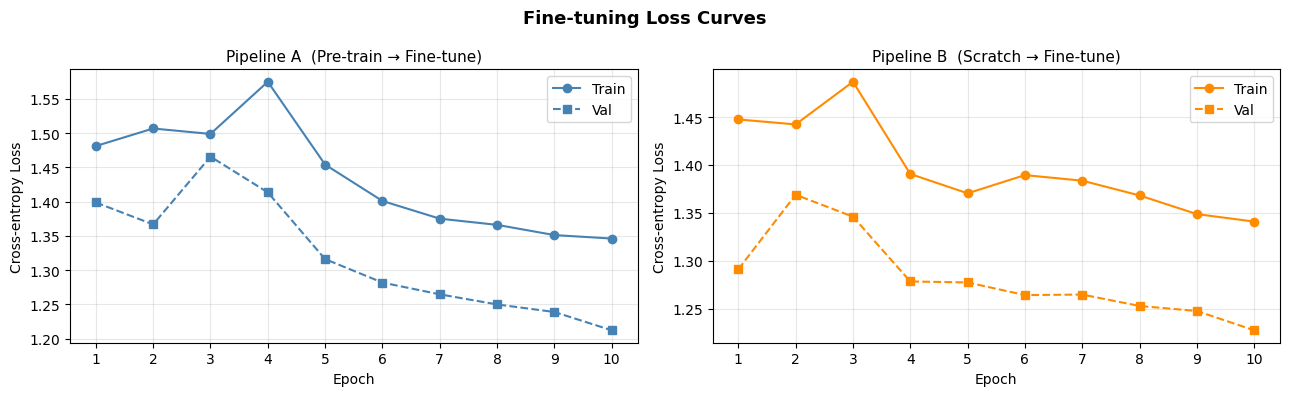

Saved → outputs/results/finetuning_loss_curves.png


In [35]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, path, label, color in [
    (axes[0], 'outputs/finetuned_a/history.json',
     'Pipeline A  (Pre-train → Fine-tune)', 'steelblue'),
    (axes[1], 'outputs/finetuned_b/history.json',
     'Pipeline B  (Scratch → Fine-tune)', 'darkorange'),
]:
    with open(path) as fh:
        history = json.load(fh)
    epochs      = [h['epoch']      for h in history]
    train_loss  = [h['train_loss'] for h in history]
    val_loss    = [h['val_loss']   for h in history]
    ax.plot(epochs, train_loss, marker='o', color=color,        label='Train')
    ax.plot(epochs, val_loss,   marker='s', color=color, ls='--', label='Val')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cross-entropy Loss')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Fine-tuning Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/results/finetuning_loss_curves.png', dpi=120)
plt.show()
print('Saved → outputs/results/finetuning_loss_curves.png')

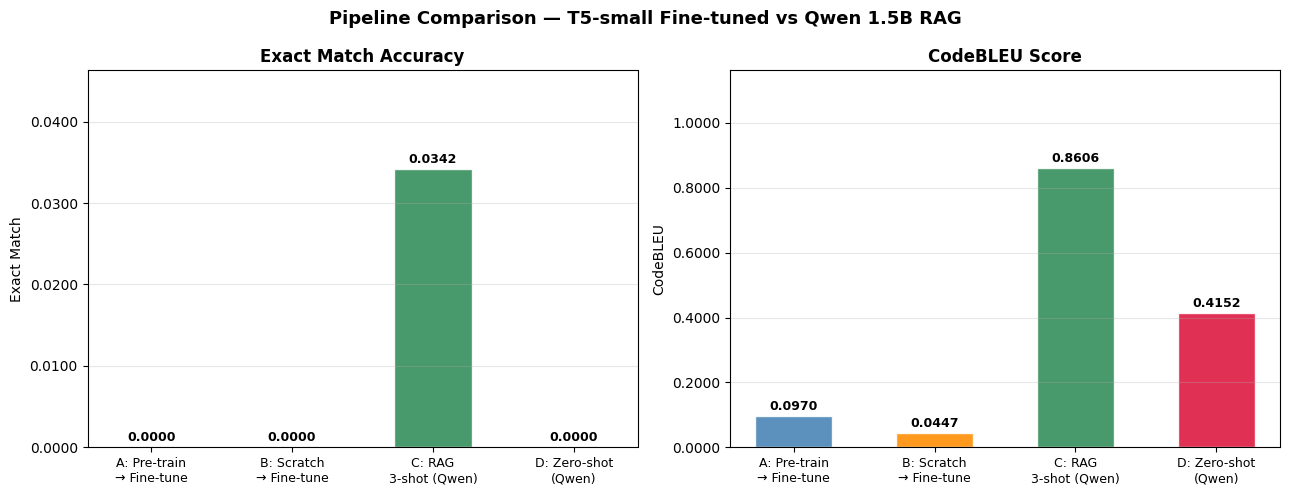

Saved → outputs/results/pipeline_comparison.png


In [36]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open('outputs/results/final_metrics.json') as fh:
    all_metrics = json.load(fh)

short_labels = [
    'A: Pre-train\n→ Fine-tune',
    'B: Scratch\n→ Fine-tune',
    'C: RAG\n3-shot (Qwen)',
    'D: Zero-shot\n(Qwen)',
]
em_scores = [m['exact_match'] for m in all_metrics]
cb_scores = [m['codebleu']    for m in all_metrics]
palette   = ['steelblue', 'darkorange', 'seagreen', 'crimson']

x = np.arange(len(short_labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, scores, ylabel, title in [
    (axes[0], em_scores, 'Exact Match', 'Exact Match Accuracy'),
    (axes[1], cb_scores, 'CodeBLEU',   'CodeBLEU Score'),
]:
    bars = ax.bar(x, scores, width=0.55, color=palette, alpha=0.88, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(scores) * 1.35 + 1e-4)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(scores) * 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Pipeline Comparison — T5-small Fine-tuned vs Qwen 1.5B RAG',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/results/pipeline_comparison.png', dpi=120)
plt.show()
print('Saved → outputs/results/pipeline_comparison.png')